#### calculate RWI - Three methods (ROI, scene, sample)

RWI CALCULATOR - Simplified Version
📥 Loading: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\Leipzig.tif
   • CRS: EPSG:4326
   • Size: 3601 x 1513
   • Bands: 12
   • Green: 5,448,313 valid, range [0.008, 1.414]
   • SWIR1: 5,448,313 valid, range [0.007, 1.341]

🔷 Method 1: 70% ROI
   ✓ n = 5.139418
✓ Saved: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\rwi_output\RWI_70pct_roi.tif

🔷 Method 2: 200 samples
   ✓ n = 5.175454
✓ Saved: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\rwi_output\RWI_200samples.tif

🔷 Method 3: Entire scene
   ✓ n = 5.015679
✓ Saved: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\rwi_output\RWI_entire_scene.tif

📊 RWI Output (Entire Scene):
   • Range: [-0.806, 0.813]
   • Valid pixels: 5,448,313

🔍 Manual Pixel Validation (adjust coordinates as needed):
   Example: y=500, x=300
   Pixel (500, 300):
   • Green: 0.097500
   • SWIR1: 0.263500
   • RWI: -0.513615
   • Excel check: -0.513615

📊 Generating comparison plot...
✓ Saved plot: C:\Users\eduju\One

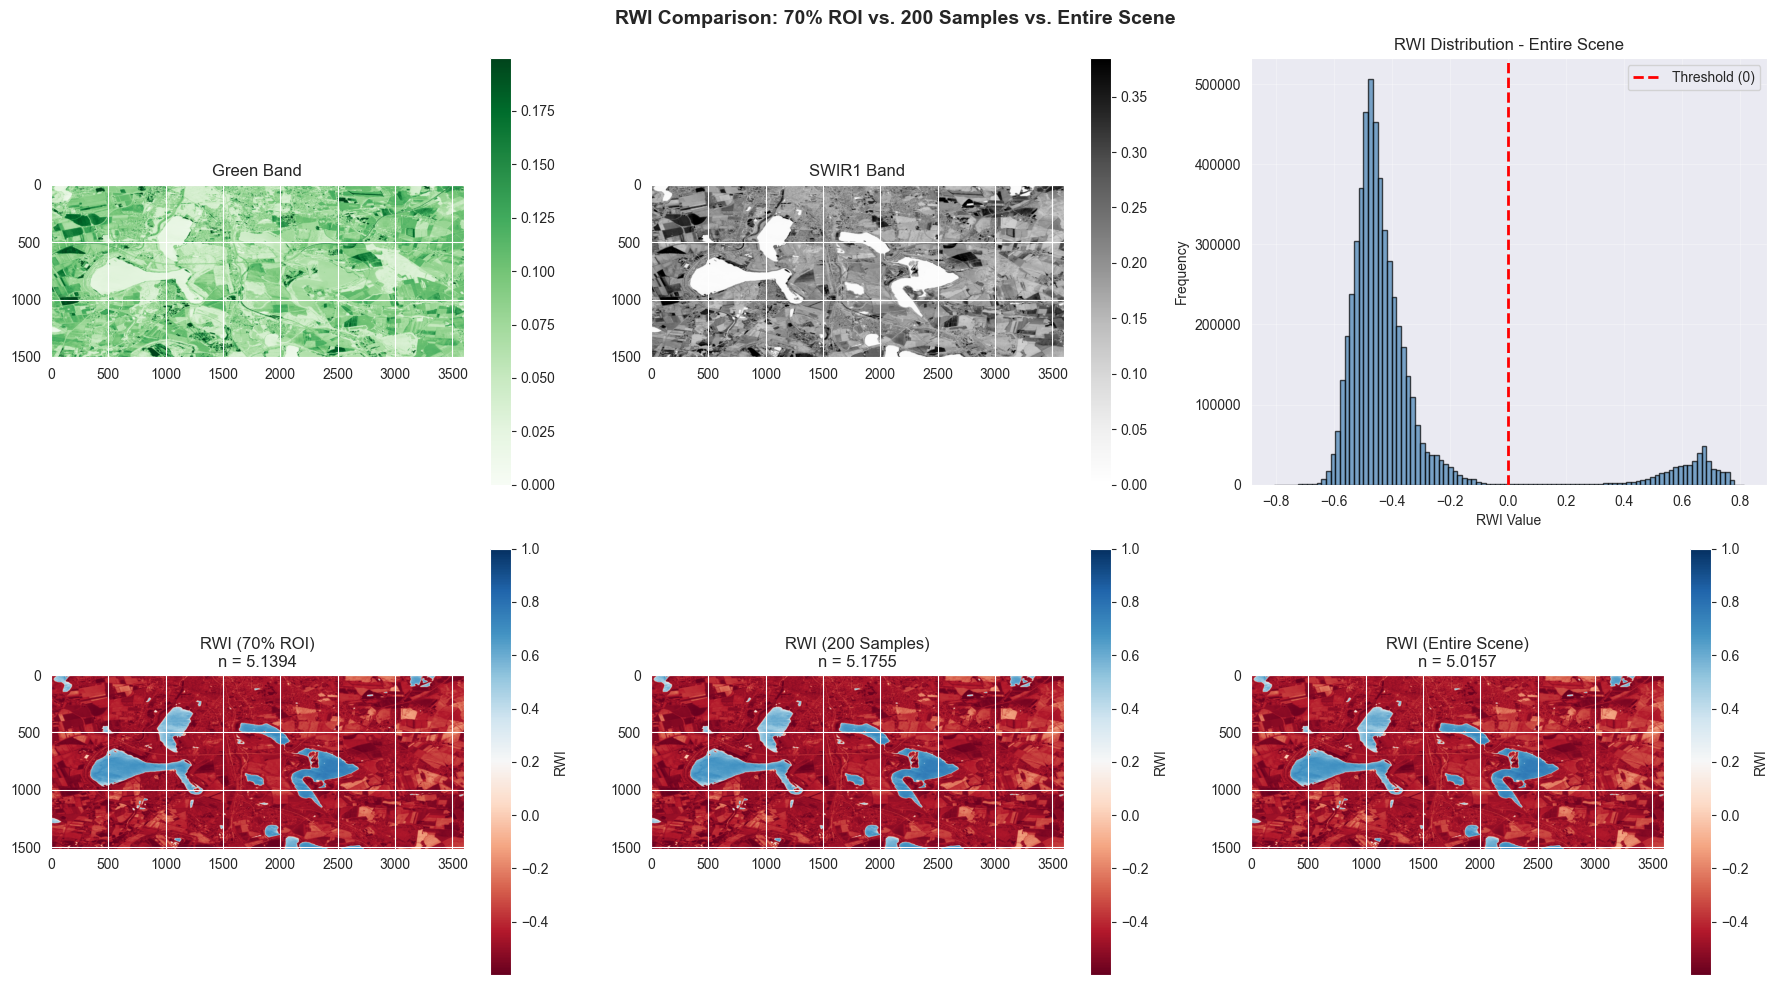


📊 RWI STATISTICS - Entire Scene
Min:     -0.806
Max:     0.813
Mean:    -0.361
Median:  -0.452
Std Dev: 0.301

Water (RWI > 0):  448,486 pixels
Non-water (RWI ≤ 0): 4,999,827 pixels
✓ Saved metadata: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\rwi_output\metadata.json

✅ PROCESSING COMPLETE


In [1]:
"""
Rescaled Water Index (RWI) - Multispectral Image Processor
===========================================================
Calculates RWI with support for ANY reflectance scale.

Simplified version: No automatic solar panel detection.
User can manually inspect pixel values for validation.

Author: Dr. Eduardo Felix Justiniano
Reference: Justiniano et al. (2025), IEEE J-STARS
DOI: https://doi.org/10.1109/JSTARS.2025.3562089
"""

import numpy as np
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import os
from typing import Union, Optional, Dict
import warnings
import json

# ============================================================================
# CONSTANTS
# ============================================================================

EULER = np.exp(1)
RWI_EXPONENT = 1 / EULER
MIN_VALID_PIXELS = 100
MIN_VALID_SAMPLES = 50
MIN_VALID_FRACTION = 0.01

SENTINEL2_BANDS = {'Green': 3, 'SWIR1': 11}
LANDSAT8_9_BANDS = {'Green': 2, 'SWIR1': 6}


# ============================================================================
# HELPER: Convert numpy types to Python native (for JSON)
# ============================================================================

def convert_to_native(obj):
    """Recursively convert numpy types to Python native types for JSON."""
    if isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(i) for i in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.bool_):
        return bool(obj)
    else:
        return obj


# ============================================================================
# RWI FACTOR N CALCULATION
# ============================================================================

def calculate_n_from_roi(
    green_band: Union[np.ndarray, xr.DataArray],
    roi_mask: Optional[Union[np.ndarray, xr.DataArray]] = None,
    nodata: Optional[Union[int, float]] = None,
    min_valid_pixels: int = MIN_VALID_PIXELS,
    use_percentile_filter: bool = True,
    percentile_range: tuple = (1, 99)
) -> float:
    """Calculate RWI normalization factor 'n' using ROI."""
    if isinstance(green_band, xr.DataArray):
        green_arr = green_band.values.copy()
    else:
        green_arr = np.asarray(green_band, dtype=float).copy()

    if roi_mask is not None:
        roi_arr = roi_mask.values if isinstance(roi_mask, xr.DataArray) else np.asarray(roi_mask, dtype=bool)
        green_arr = np.where(roi_arr, green_arr, np.nan)

    if nodata is not None:
        green_arr = np.where(green_arr == nodata, np.nan, green_arr)

    valid_mask = np.isfinite(green_arr) & (green_arr >= 0)

    if use_percentile_filter:
        valid_values = green_arr[valid_mask]
        if len(valid_values) > 100:
            p_low, p_high = np.percentile(valid_values, percentile_range)
            valid_mask = valid_mask & (green_arr >= p_low) & (green_arr <= p_high)

    green_valid = green_arr[valid_mask]

    if len(green_valid) < min_valid_pixels:
        green_valid = green_arr[np.isfinite(green_arr) & (green_arr >= 0)]
        if len(green_valid) < min_valid_pixels:
            raise ValueError(f"Insufficient valid pixels: {len(green_valid)} < {min_valid_pixels}")

    median_g = np.median(green_valid)
    median_g_exp = np.median(np.power(green_valid, RWI_EXPONENT))

    if median_g == 0:
        return 1.0

    return float(median_g_exp / median_g)


def calculate_n_from_samples(
    green_values: Union[np.ndarray, list],
    sample_mask: Optional[Union[np.ndarray, list]] = None,
    nodata: Optional[Union[int, float]] = None,
    min_valid_samples: int = MIN_VALID_SAMPLES,
    use_percentile_filter: bool = True,
    percentile_range: tuple = (1, 99)
) -> float:
    """Calculate n from samples."""
    green_arr = np.asarray(green_values, dtype=float).copy()

    if sample_mask is not None:
        green_arr = green_arr[np.asarray(sample_mask, dtype=bool)]

    if nodata is not None:
        green_arr = np.where(green_arr == nodata, np.nan, green_arr)

    valid_mask = np.isfinite(green_arr) & (green_arr >= 0)

    if use_percentile_filter:
        valid_values = green_arr[valid_mask]
        if len(valid_values) > 50:
            p_low, p_high = np.percentile(valid_values, percentile_range)
            valid_mask = valid_mask & (green_arr >= p_low) & (green_arr <= p_high)

    green_valid = green_arr[valid_mask]

    if len(green_valid) < min_valid_samples:
        green_valid = green_arr[np.isfinite(green_arr) & (green_arr >= 0)]
        if len(green_valid) < min_valid_samples:
            raise ValueError(f"Insufficient valid samples: {len(green_valid)} < {min_valid_samples}")

    median_g = np.median(green_valid)
    median_g_exp = np.median(np.power(green_valid, RWI_EXPONENT))

    if median_g == 0:
        return 1.0

    return float(median_g_exp / median_g)


def calculate_n_from_image(
    green_band: Union[np.ndarray, xr.DataArray],
    nodata: Optional[Union[int, float]] = None,
    min_valid_fraction: float = MIN_VALID_FRACTION,
    max_pixels_for_exact: int = 1000000,
    use_percentile_filter: bool = True,
    percentile_range: tuple = (1, 99)
) -> float:
    """Calculate n from entire image."""
    if isinstance(green_band, xr.DataArray):
        green_arr = green_band.values.ravel().copy()
    else:
        green_arr = np.asarray(green_band, dtype=float).ravel().copy()

    if nodata is not None:
        green_arr = np.where(green_arr == nodata, np.nan, green_arr)

    valid_mask = np.isfinite(green_arr) & (green_arr >= 0)

    if use_percentile_filter:
        valid_values = green_arr[valid_mask]
        if len(valid_values) > 1000:
            p_low, p_high = np.percentile(valid_values, percentile_range)
            valid_mask = valid_mask & (green_arr >= p_low) & (green_arr <= p_high)

    green_valid = green_arr[valid_mask]

    total_pixels = len(green_arr)
    if len(green_valid) / total_pixels < min_valid_fraction:
        green_valid = green_arr[np.isfinite(green_arr) & (green_arr >= 0)]

    if len(green_valid) == 0:
        return 1.0

    if len(green_valid) > max_pixels_for_exact:
        np.random.seed(42)
        sample_idx = np.random.choice(len(green_valid), size=max_pixels_for_exact, replace=False)
        green_sample = green_valid[sample_idx]
        median_g = np.median(green_sample)
        median_g_exp = np.median(np.power(green_sample, RWI_EXPONENT))
    else:
        median_g = np.median(green_valid)
        median_g_exp = np.median(np.power(green_valid, RWI_EXPONENT))

    if median_g == 0:
        return 1.0

    return float(median_g_exp / median_g)


# ============================================================================
# RWI CALCULATION
# ============================================================================

def calculate_rwi(
    green: Union[np.ndarray, xr.DataArray],
    swir1: Union[np.ndarray, xr.DataArray],
    n_factor: float
) -> Union[np.ndarray, xr.DataArray]:
    """Calculate RWI - preserves all valid numeric values."""
    is_xarray = isinstance(green, xr.DataArray)

    if is_xarray:
        green_arr = green.values.astype(float)
        swir1_arr = swir1.values.astype(float)
    else:
        green_arr = np.asarray(green, dtype=float)
        swir1_arr = np.asarray(swir1, dtype=float)

    green_exp = np.power(green_arr, RWI_EXPONENT)
    green_adj = green_exp / n_factor

    with np.errstate(divide='ignore', invalid='ignore'):
        rwi_arr = (green_adj - swir1_arr) / (green_adj + swir1_arr)

    rwi_arr = np.where(np.isfinite(rwi_arr), rwi_arr, np.nan)

    if is_xarray:
        rwi = xr.DataArray(
            rwi_arr, dims=green.dims, coords=green.coords,
            attrs={
                'long_name': 'Rescaled Water Index',
                'formula': '(Green^(1/e)/n - SWIR1) / (Green^(1/e)/n + SWIR1)',
                'n_factor': n_factor,
                'exponent': RWI_EXPONENT,
                'reference': 'Justiniano & Kawakubo (2025), IEEE J-STARS'
            }
        )
        return rwi
    else:
        return rwi_arr


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_multispectral_image(
    filepath: str,
    band_indices: Dict[str, int],
    nodata_value: Optional[float] = None
) -> Dict[str, xr.DataArray]:
    """Load multispectral GeoTIFF - no range filtering."""
    print(f"📥 Loading: {filepath}")

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Image not found: {filepath}")

    with rasterio.open(filepath) as src:
        print(f"   • CRS: {src.crs}")
        print(f"   • Size: {src.width} x {src.height}")
        print(f"   • Bands: {src.count}")

        bands = {}
        for band_name, band_idx in band_indices.items():
            if band_idx > src.count:
                warnings.warn(f"Band {band_idx} ({band_name}) not available.")
                continue

            data = src.read(band_idx).astype('float64')

            if nodata_value is not None:
                data = np.where(data == nodata_value, np.nan, data)

            data = np.where(data < 0, np.nan, data)

            bands[band_name] = xr.DataArray(
                data, dims=['y', 'x'],
                coords={'y': np.arange(data.shape[0]), 'x': np.arange(data.shape[1])},
                attrs={'band_index': band_idx, 'crs': str(src.crs)}
            )

            valid = data[~np.isnan(data)]
            if len(valid) > 0:
                print(f"   • {band_name}: {len(valid):,} valid, "
                      f"range [{np.nanmin(data):.3f}, {np.nanmax(data):.3f}]")

    return bands


def create_roi_70percent(data_array: xr.DataArray) -> xr.DataArray:
    """Create ROI mask covering 70% of image area."""
    height, width = data_array.shape
    side_factor = np.sqrt(0.7)
    roi_height = int(height * side_factor)
    roi_width = int(width * side_factor)

    y_start = (height - roi_height) // 2
    x_start = (width - roi_width) // 2

    mask = np.zeros((height, width), dtype=bool)
    mask[y_start:y_start+roi_height, x_start:x_start+roi_width] = True

    return xr.DataArray(mask, dims=['y', 'x'], coords=data_array.coords)


def generate_random_samples(
    data_array: xr.DataArray,
    n_samples: int = 200,
    seed: int = 42
) -> np.ndarray:
    """Generate random samples from valid pixels."""
    np.random.seed(seed)

    valid_mask = (~np.isnan(data_array.values)) & (data_array.values >= 0)
    valid_indices = np.argwhere(valid_mask)

    if len(valid_indices) < n_samples:
        warnings.warn(f"Only {len(valid_indices)} valid pixels found; using all.")
        return data_array.values[valid_mask]

    selected_idx = np.random.choice(len(valid_indices), size=n_samples, replace=False)
    sample_coords = valid_indices[selected_idx]

    return data_array.values[sample_coords[:, 0], sample_coords[:, 1]]


def save_raster(data_array: xr.DataArray, output_path: str, reference_path: str, dtype: str = 'float32') -> None:
    """Save xarray DataArray as GeoTIFF."""
    with rasterio.open(reference_path) as src:
        profile = src.profile.copy()
        profile.update(dtype=dtype, count=1, nodata=-9999, compress='lzw')
        data = data_array.values.astype(dtype)
        data = np.where(np.isnan(data), -9999, data)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data, 1)
    print(f"✓ Saved: {output_path}")


# ============================================================================
# PLOT FUNCTION - CORRECTED LAYOUT
# ============================================================================

def plot_comparison(green, swir1, rwi_roi, rwi_samples, rwi_full, n_factors, output_path=None):
    """
    Create comparison plot with corrected layout:
    - Row 1: Green, SWIR1, RWI Distribution histogram
    - Row 2: RWI results (3 methods)
    - Statistics printed to console (not in plot)
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Changed to 2x3 layout
    fig.suptitle('RWI Comparison: 70% ROI vs. 200 Samples vs. Entire Scene',
                 fontsize=14, fontweight='bold')

    # Row 1: Input bands + Distribution histogram
    vmax_green = np.nanpercentile(green.values, 99)
    im1 = axes[0, 0].imshow(green.values, cmap='Greens', vmin=0, vmax=vmax_green)
    axes[0, 0].set_title('Green Band')
    plt.colorbar(im1, ax=axes[0, 0])

    vmax_swir = np.nanpercentile(swir1.values, 99)
    im2 = axes[0, 1].imshow(swir1.values, cmap='Greys', vmin=0, vmax=vmax_swir)
    axes[0, 1].set_title('SWIR1 Band')
    plt.colorbar(im2, ax=axes[0, 1])

    # CORRECTION: Histogram in top-right with proper title
    valid_rwi = rwi_full.values[~np.isnan(rwi_full.values)]
    axes[0, 2].hist(valid_rwi, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Threshold (0)')
    axes[0, 2].set_title('RWI Distribution - Entire Scene')  # CORRECTED TITLE
    axes[0, 2].set_xlabel('RWI Value')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Row 2: RWI results (3 methods)
    rwi_max = np.nanpercentile(rwi_full.values, 99)
    rwi_min = np.nanpercentile(rwi_full.values, 1)

    for idx, (rwi, title, n_val) in enumerate([
        (rwi_roi, '70% ROI', n_factors['roi']),
        (rwi_samples, '200 Samples', n_factors['samples']),
        (rwi_full, 'Entire Scene', n_factors['full'])
    ]):
        im = axes[1, idx].imshow(rwi.values, cmap='RdBu', vmin=rwi_min, vmax=max(rwi_max, 1))
        axes[1, idx].set_title(f'RWI ({title})\nn = {n_val:.4f}')
        plt.colorbar(im, ax=axes[1, idx], label='RWI')

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved plot: {output_path}")

    plt.show()

    # CORRECTION: Print statistics to console (outside the plot)
    print("\n" + "="*50)
    print("📊 RWI STATISTICS - Entire Scene")
    print("="*50)
    print(f"Min:     {np.nanmin(rwi_full.values):.3f}")
    print(f"Max:     {np.nanmax(rwi_full.values):.3f}")
    print(f"Mean:    {np.nanmean(rwi_full.values):.3f}")
    print(f"Median:  {np.nanmedian(rwi_full.values):.3f}")
    print(f"Std Dev: {np.nanstd(rwi_full.values):.3f}")
    print(f"\nWater (RWI > 0):  {np.count_nonzero(rwi_full.values > 0):,} pixels")
    print(f"Non-water (RWI ≤ 0): {np.count_nonzero(rwi_full.values <= 0):,} pixels")
    print("="*50)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution - simplified, no solar panel detection."""

    # USER CONFIGURATION
    IMAGE_PATH = r'C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\Leipzig.tif'
    OUTPUT_DIR = r'C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\rwi_output'
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    SENSOR = 'sentinel2'
    NODATA = -9999.0
    N_SAMPLES = 200

    USE_PERCENTILE_FILTER = True
    PERCENTILE_RANGE = (1, 99)

    band_indices = SENTINEL2_BANDS if SENSOR.lower() == 'sentinel2' else LANDSAT8_9_BANDS

    print("="*60)
    print("RWI CALCULATOR - Simplified Version")
    print("="*60)

    # Load data
    bands = load_multispectral_image(IMAGE_PATH, band_indices, nodata_value=NODATA)
    green = bands['Green']
    swir1 = bands['SWIR1']

    # METHOD 1: 70% ROI
    print("\n🔷 Method 1: 70% ROI")
    roi_mask = create_roi_70percent(green)
    n_roi = calculate_n_from_roi(green, roi_mask=roi_mask, nodata=NODATA,
                                  use_percentile_filter=USE_PERCENTILE_FILTER,
                                  percentile_range=PERCENTILE_RANGE)
    print(f"   ✓ n = {n_roi:.6f}")
    rwi_roi = calculate_rwi(green, swir1, n_roi)
    save_raster(rwi_roi, os.path.join(OUTPUT_DIR, 'RWI_70pct_roi.tif'), IMAGE_PATH)

    # METHOD 2: 200 Samples
    print(f"\n🔷 Method 2: {N_SAMPLES} samples")
    green_samples = generate_random_samples(green, n_samples=N_SAMPLES, seed=42)
    n_samples = calculate_n_from_samples(green_samples, nodata=NODATA,
                                          use_percentile_filter=USE_PERCENTILE_FILTER,
                                          percentile_range=PERCENTILE_RANGE)
    print(f"   ✓ n = {n_samples:.6f}")
    rwi_samples = calculate_rwi(green, swir1, n_samples)
    save_raster(rwi_samples, os.path.join(OUTPUT_DIR, f'RWI_{N_SAMPLES}samples.tif'), IMAGE_PATH)

    # METHOD 3: Entire Scene
    print("\n🔷 Method 3: Entire scene")
    n_full = calculate_n_from_image(green, nodata=NODATA,
                                     use_percentile_filter=USE_PERCENTILE_FILTER,
                                     percentile_range=PERCENTILE_RANGE)
    print(f"   ✓ n = {n_full:.6f}")
    rwi_full = calculate_rwi(green, swir1, n_full)
    save_raster(rwi_full, os.path.join(OUTPUT_DIR, 'RWI_entire_scene.tif'), IMAGE_PATH)

    # Diagnostic output
    print(f"\n📊 RWI Output (Entire Scene):")
    print(f"   • Range: [{np.nanmin(rwi_full.values):.3f}, {np.nanmax(rwi_full.values):.3f}]")
    print(f"   • Valid pixels: {np.count_nonzero(~np.isnan(rwi_full.values)):,}")

    # Optional: Manual pixel validation
    print("\n🔍 Manual Pixel Validation (adjust coordinates as needed):")
    print("   Example: y=500, x=300")
    y, x = 500, 300
    if y < green.shape[0] and x < green.shape[1]:
        g_val = green.values[y, x]
        s_val = swir1.values[y, x]
        r_val = rwi_full.values[y, x]
        if not np.isnan(r_val):
            expected = ((g_val**RWI_EXPONENT)/n_full - s_val) / ((g_val**RWI_EXPONENT)/n_full + s_val)
            print(f"   Pixel ({y}, {x}):")
            print(f"   • Green: {g_val:.6f}")
            print(f"   • SWIR1: {s_val:.6f}")
            print(f"   • RWI: {r_val:.6f}")
            print(f"   • Excel check: {expected:.6f}")

    # Visualization (CORRECTED LAYOUT)
    print("\n📊 Generating comparison plot...")
    plot_comparison(green, swir1, rwi_roi, rwi_samples, rwi_full,
                    {'roi': n_roi, 'samples': n_samples, 'full': n_full},
                    output_path=os.path.join(OUTPUT_DIR, 'rwi_comparison.png'))

    # Save metadata
    metadata = convert_to_native({
        'n_factors': {'roi': n_roi, 'samples': n_samples, 'full': n_full},
        'exponent': RWI_EXPONENT,
        'reference': 'Justiniano & Kawakubo (2025), IEEE J-STARS',
        'doi': 'https://doi.org/10.1109/JSTARS.2025.3562089',
        'rwi_statistics': {
            'min': float(np.nanmin(rwi_full.values)),
            'max': float(np.nanmax(rwi_full.values)),
            'mean': float(np.nanmean(rwi_full.values)),
            'valid_pixels': int(np.count_nonzero(~np.isnan(rwi_full.values)))
        },
        'note': 'All valid values preserved; user can manually inspect pixels for validation'
    })

    with open(os.path.join(OUTPUT_DIR, 'metadata.json'), 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    print(f"✓ Saved metadata: {os.path.join(OUTPUT_DIR, 'metadata.json')}")

    print("\n✅ PROCESSING COMPLETE")
    print("="*60)


if __name__ == '__main__':
    main()

#### index comparison

WATER INDEX COMPARISON: RWI vs. NDWI vs. MNDWI
📥 Loading: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\Leipzig.tif
   • Bands: 12, CRS: EPSG:4326
   • Green: 5,448,313 valid, range [0.008, 1.414], >1: 961 (0.0%)
   • NIR: 5,448,313 valid, range [0.007, 1.400], >1: 1,067 (0.0%)
   • SWIR1: 5,448,313 valid, range [0.007, 1.341], >1: 1,392 (0.0%)

🔷 Calculating indices...
   ✓ Factor n (RWI): 5.015679
   ✓ RWI range: [-0.806, 0.813]
   ✓ NDWI range: [-0.912, 0.732]
   ✓ MNDWI range: [-0.875, 0.794]
✓ Saved: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\RWI.tif
✓ Saved: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\NDWI.tif
✓ Saved: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\MNDWI.tif

📊 Generating comparison plot...
   • RWI water pixels: 448,486 (8.23%)
   • NDWI water pixels: 439,103 (8.06%)
   • MNDWI water pixels: 440,555 (8.09%)
✓ Saved plot: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\index_compariso

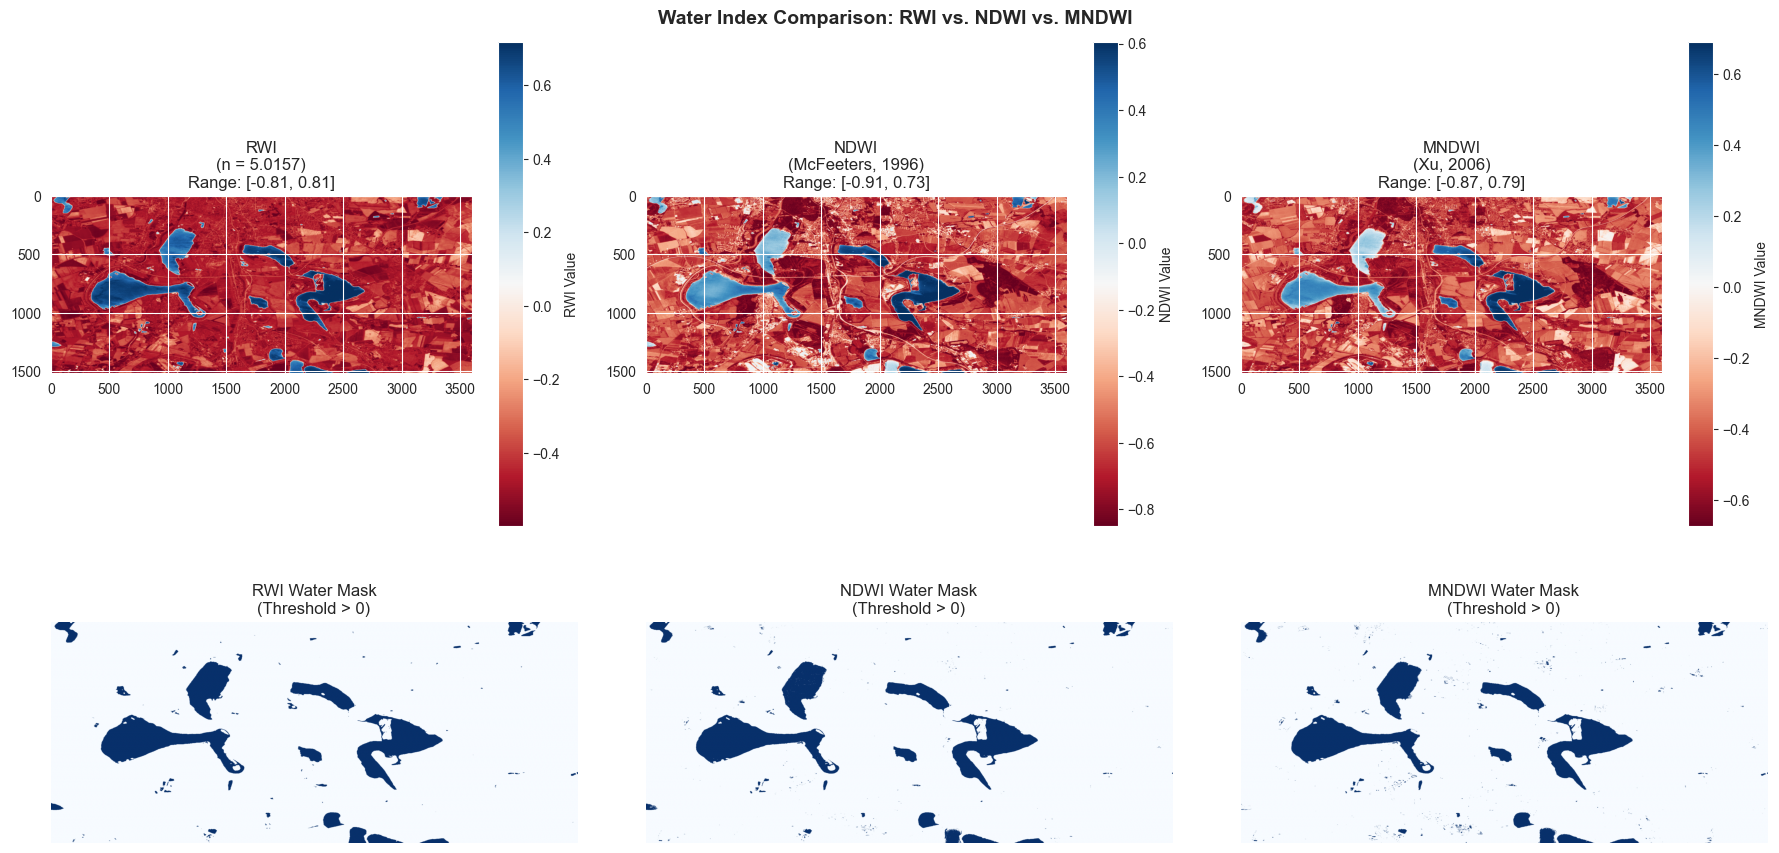


📊 INDEX STATISTICS

RWI:
   • Range: [-0.806, 0.813]
   • Mean: -0.361, Std: 0.301
   • Values > 1: 0 (0.000%)

NDWI:
   • Range: [-0.912, 0.732]
   • Mean: -0.528, Std: 0.311
   • Values > 1: 0 (0.000%)

MNDWI:
   • Range: [-0.875, 0.794]
   • Mean: -0.370, Std: 0.273
   • Values > 1: 0 (0.000%)
✓ Saved statistics: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\comparison_statistics.json

✅ COMPARISON COMPLETE
📁 Output: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison
📄 RWI: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\RWI.tif
📄 NDWI: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\NDWI.tif
📄 MNDWI: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\MNDWI.tif
📈 Plot: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\index_comparison.png
📊 Stats: C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison\comparison_statistics.json

💡 Tip: Check console output for values > 1 (poten

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Water Index Comparison: RWI vs. NDWI vs. MNDWI
===============================================
Compares all three indices WITHOUT clipping values.
Accepts anomalous values (> 1) for solar panel detection.

Author: Dr. Eduardo Felix Justiniano
Reference: Justiniano & Kawakubo (2025), IEEE J-STARS
DOI: https://doi.org/10.1109/JSTARS.2025.3562089
"""

import numpy as np
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import os
from typing import Union, Optional, Dict
import json

# ============================================================================
# CONSTANTS
# ============================================================================

EULER = np.exp(1)
RWI_EXPONENT = 1 / EULER

SENTINEL2_BANDS = {'Green': 3, 'NIR': 8, 'SWIR1': 11}
LANDSAT8_9_BANDS = {'Green': 2, 'NIR': 4, 'SWIR1': 6}


# ============================================================================
# INDEX CALCULATION FUNCTIONS (Accept Any Valid Value)
# ============================================================================

def calculate_n_from_image(green_band: xr.DataArray, nodata: Optional[float] = None) -> float:
    """Calculate RWI normalization factor n - accepts any non-negative finite value."""
    green_arr = green_band.values.ravel()

    if nodata is not None:
        green_arr = np.where(green_arr == nodata, np.nan, green_arr)

    # CORRECTION: Accept values > 1 (only filter negative and inf)
    green_valid = green_arr[
        (green_arr >= 0) & np.isfinite(green_arr)
    ]

    if len(green_valid) == 0:
        return 1.0

    median_g = np.median(green_valid)
    median_g_exp = np.median(np.power(green_valid, RWI_EXPONENT))

    return float(median_g_exp / median_g) if median_g != 0 else 1.0


def calculate_rwi(green: xr.DataArray, swir1: xr.DataArray, n_factor: float) -> xr.DataArray:
    """Calculate RWI - preserves all valid values including > 1."""
    green_exp = np.power(green.values, RWI_EXPONENT)
    green_adj = green_exp / n_factor

    with np.errstate(divide='ignore', invalid='ignore'):
        rwi = (green_adj - swir1.values) / (green_adj + swir1.values)

    # Only mask truly invalid (inf, nan), NOT high values
    rwi = np.where(np.isfinite(rwi), rwi, np.nan)

    return xr.DataArray(
        rwi, dims=green.dims, coords=green.coords,
        attrs={
            'long_name': 'Rescaled Water Index',
            'formula': '(Green^(1/e)/n - SWIR1) / (Green^(1/e)/n + SWIR1)',
            'note': 'Values > 1 preserved for anomaly detection'
        }
    )


def calculate_ndwi(green: xr.DataArray, nir: xr.DataArray) -> xr.DataArray:
    """Calculate NDWI - preserves all valid values."""
    with np.errstate(divide='ignore', invalid='ignore'):
        ndwi = (green.values - nir.values) / (green.values + nir.values)

    ndwi = np.where(np.isfinite(ndwi), ndwi, np.nan)

    return xr.DataArray(
        ndwi, dims=green.dims, coords=green.coords,
        attrs={
            'long_name': 'Normalized Difference Water Index',
            'formula': '(Green - NIR) / (Green + NIR)',
            'reference': 'McFeeters (1996)'
        }
    )


def calculate_mndwi(green: xr.DataArray, swir1: xr.DataArray) -> xr.DataArray:
    """Calculate MNDWI - preserves all valid values."""
    with np.errstate(divide='ignore', invalid='ignore'):
        mndwi = (green.values - swir1.values) / (green.values + swir1.values)

    mndwi = np.where(np.isfinite(mndwi), mndwi, np.nan)

    return xr.DataArray(
        mndwi, dims=green.dims, coords=green.coords,
        attrs={
            'long_name': 'Modified Normalized Difference Water Index',
            'formula': '(Green - SWIR1) / (Green + SWIR1)',
            'reference': 'Xu (2006)'
        }
    )


# ============================================================================
# HELPER FUNCTIONS (Accept Any Valid Value)
# ============================================================================

def load_multispectral_image(
    filepath: str,
    band_indices: Dict[str, int],
    nodata_value: Optional[float] = None
) -> Dict[str, xr.DataArray]:
    """Load multispectral GeoTIFF - CORRECTED: accepts values > 1."""
    print(f"📥 Loading: {filepath}")

    with rasterio.open(filepath) as src:
        print(f"   • Bands: {src.count}, CRS: {src.crs}")

        bands = {}
        for band_name, band_idx in band_indices.items():
            data = src.read(band_idx).astype('float64')  # Use float64 for precision

            if nodata_value is not None:
                data = np.where(data == nodata_value, np.nan, data)

            # CORRECTION: Only mask negative values (truly invalid)
            # Values > 1 are PRESERVED for anomaly/solar panel detection
            data = np.where(data < 0, np.nan, data)
            # REMOVED: data = np.where((data < 0) | (data > 1), np.nan, data)

            bands[band_name] = xr.DataArray(
                data,
                dims=['y', 'x'],
                coords={'y': np.arange(data.shape[0]), 'x': np.arange(data.shape[1])}
            )

            # Diagnostic: report values > 1
            valid = data[~np.isnan(data)]
            if len(valid) > 0:
                above_1 = np.count_nonzero(valid > 1)
                print(f"   • {band_name}: {len(valid):,} valid, "
                      f"range [{np.nanmin(data):.3f}, {np.nanmax(data):.3f}], "
                      f">1: {above_1:,} ({above_1/len(valid)*100:.1f}%)")

    return bands


def plot_index_comparison(
    rwi: xr.DataArray,
    ndwi: xr.DataArray,
    mndwi: xr.DataArray,
    n_factor: float,
    output_path: Optional[str] = None
) -> None:
    """
    Compare all three indices - SIMPLIFIED LAYOUT (2 rows × 3 columns).

    Row 1: Index maps (full range)
    Row 2: Binary water masks (threshold > 0)
    """
    # CORRECTION: Changed from (3, 4) to (2, 3) - removed last row and column
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Water Index Comparison: RWI vs. NDWI vs. MNDWI',
                 fontsize=14, fontweight='bold')

    indices = {
        'RWI': (rwi, f'RWI\n(n = {n_factor:.4f})'),
        'NDWI': (ndwi, 'NDWI\n(McFeeters, 1996)'),
        'MNDWI': (mndwi, 'MNDWI\n(Xu, 2006)')
    }

    # Row 1: Index maps (full range, dynamic vmin/vmax)
    for idx, (name, (data, title)) in enumerate(indices.items()):
        # Use percentile-based limits for better visualization
        vmin = np.nanpercentile(data.values, 1)
        vmax = np.nanpercentile(data.values, 99)
        # Ensure we capture anomalies > 1 if they exist
        if np.nanmax(data.values) > 1:
            vmax = max(vmax, np.nanmax(data.values))

        im = axes[0, idx].imshow(data.values, cmap='RdBu', vmin=vmin, vmax=vmax, aspect='equal')
        axes[0, idx].set_title(f'{title}\nRange: [{np.nanmin(data.values):.2f}, {np.nanmax(data.values):.2f}]')
        plt.colorbar(im, ax=axes[0, idx], label=f'{name} Value')

    # Row 2: Binary water masks (threshold > 0)
    for idx, (name, (data, title)) in enumerate(indices.items()):
        water_mask = data.values > 0
        im = axes[1, idx].imshow(water_mask, cmap='Blues', aspect='equal')
        axes[1, idx].set_title(f'{name} Water Mask\n(Threshold > 0)')
        axes[1, idx].axis('off')

        water_pixels = np.count_nonzero(water_mask)
        water_pct = water_pixels / data.size * 100
        print(f"   • {name} water pixels: {water_pixels:,} ({water_pct:.2f}%)")

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved plot: {output_path}")

    plt.show()

    # Print statistics to console (outside the plot)
    print("\n" + "="*60)
    print("📊 INDEX STATISTICS")
    print("="*60)
    for name, data in [('RWI', rwi), ('NDWI', ndwi), ('MNDWI', mndwi)]:
        valid = data.values[~np.isnan(data.values)]
        above_1 = np.count_nonzero(data.values > 1)
        print(f"\n{name}:")
        print(f"   • Range: [{np.nanmin(data.values):.3f}, {np.nanmax(data.values):.3f}]")
        print(f"   • Mean: {np.nanmean(data.values):.3f}, Std: {np.nanstd(data.values):.3f}")
        print(f"   • Values > 1: {above_1:,} ({above_1/len(valid)*100:.3f}%)")
    print("="*60)


def save_comparison_stats(
    rwi: xr.DataArray,
    ndwi: xr.DataArray,
    mndwi: xr.DataArray,
    n_factor: float,
    output_path: str
) -> None:
    """Save comparison statistics to JSON."""
    def count_above_1(data):
        return int(np.count_nonzero(data.values > 1))

    def pct_above_1(data):
        valid = data.values[~np.isnan(data.values)]
        return float(count_above_1(data) / len(valid) * 100) if len(valid) > 0 else 0.0

    stats = {
        'n_factor': float(n_factor),
        'indices': {
            'RWI': {
                'min': float(np.nanmin(rwi.values)),
                'max': float(np.nanmax(rwi.values)),
                'mean': float(np.nanmean(rwi.values)),
                'std': float(np.nanstd(rwi.values)),
                'values_above_1': count_above_1(rwi),
                'percentage_above_1': pct_above_1(rwi),
                'water_pixels': int(np.count_nonzero(rwi.values > 0)),
                'water_percentage': float(np.count_nonzero(rwi.values > 0) / rwi.size * 100)
            },
            'NDWI': {
                'min': float(np.nanmin(ndwi.values)),
                'max': float(np.nanmax(ndwi.values)),
                'mean': float(np.nanmean(ndwi.values)),
                'std': float(np.nanstd(ndwi.values)),
                'values_above_1': count_above_1(ndwi),
                'percentage_above_1': pct_above_1(ndwi),
                'water_pixels': int(np.count_nonzero(ndwi.values > 0)),
                'water_percentage': float(np.count_nonzero(ndwi.values > 0) / ndwi.size * 100)
            },
            'MNDWI': {
                'min': float(np.nanmin(mndwi.values)),
                'max': float(np.nanmax(mndwi.values)),
                'mean': float(np.nanmean(mndwi.values)),
                'std': float(np.nanstd(mndwi.values)),
                'values_above_1': count_above_1(mndwi),
                'percentage_above_1': pct_above_1(mndwi),
                'water_pixels': int(np.count_nonzero(mndwi.values > 0)),
                'water_percentage': float(np.count_nonzero(mndwi.values > 0) / mndwi.size * 100)
            }
        },
        'reference': 'Justiniano & Kawakubo (2025), IEEE J-STARS',
        'doi': 'https://doi.org/10.1109/JSTARS.2025.3562089',
        'note': 'Values > 1 preserved; may indicate solar panels or other anomalies'
    }

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(stats, f, indent=2, ensure_ascii=False)

    print(f"✓ Saved statistics: {output_path}")


def _save_raster_impl(data_array: xr.DataArray, output_path: str, reference_path: str, dtype: str = 'float32') -> None:
    """Save xarray DataArray as GeoTIFF."""
    with rasterio.open(reference_path) as src:
        profile = src.profile.copy()
        profile.update(dtype=dtype, count=1, nodata=-9999, compress='lzw')

        data = data_array.values.astype(dtype)
        data = np.where(np.isnan(data), -9999, data)

        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data, 1)

    print(f"✓ Saved: {output_path}")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main function for index comparison."""

    # USER CONFIGURATION
    IMAGE_PATH = r'C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\Leipzig.tif'
    OUTPUT_DIR = r'C:\Users\eduju\OneDrive\Documentos\Pesquisa\RWI\index_comparison'
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    SENSOR = 'sentinel2'
    NODATA = -9999.0

    # Select band indices
    if SENSOR.lower() == 'sentinel2':
        band_indices = SENTINEL2_BANDS.copy()
    else:
        band_indices = LANDSAT8_9_BANDS.copy()

    print("="*60)
    print("WATER INDEX COMPARISON: RWI vs. NDWI vs. MNDWI")
    print("="*60)

    # Load data (CORRECTED: accepts values > 1)
    bands = load_multispectral_image(IMAGE_PATH, band_indices, nodata_value=NODATA)
    green = bands['Green']
    nir = bands['NIR']
    swir1 = bands['SWIR1']

    # Calculate indices
    print("\n🔷 Calculating indices...")

    n_factor = calculate_n_from_image(green, nodata=NODATA)
    print(f"   ✓ Factor n (RWI): {n_factor:.6f}")

    rwi = calculate_rwi(green, swir1, n_factor)
    print(f"   ✓ RWI range: [{np.nanmin(rwi.values):.3f}, {np.nanmax(rwi.values):.3f}]")

    ndwi = calculate_ndwi(green, nir)
    print(f"   ✓ NDWI range: [{np.nanmin(ndwi.values):.3f}, {np.nanmax(ndwi.values):.3f}]")

    mndwi = calculate_mndwi(green, swir1)
    print(f"   ✓ MNDWI range: [{np.nanmin(mndwi.values):.3f}, {np.nanmax(mndwi.values):.3f}]")

    # Save indices
    save_raster = lambda data, name: _save_raster_impl(data, os.path.join(OUTPUT_DIR, f'{name}.tif'), IMAGE_PATH)

    save_raster(rwi, 'RWI')
    save_raster(ndwi, 'NDWI')
    save_raster(mndwi, 'MNDWI')

    # Generate comparison plot (SIMPLIFIED LAYOUT)
    print("\n📊 Generating comparison plot...")
    plot_path = os.path.join(OUTPUT_DIR, 'index_comparison.png')
    plot_index_comparison(rwi, ndwi, mndwi, n_factor, output_path=plot_path)

    # Save statistics
    stats_path = os.path.join(OUTPUT_DIR, 'comparison_statistics.json')
    save_comparison_stats(rwi, ndwi, mndwi, n_factor, stats_path)

    print("\n" + "="*60)
    print("✅ COMPARISON COMPLETE")
    print("="*60)
    print(f"📁 Output: {OUTPUT_DIR}")
    print(f"📄 RWI: {os.path.join(OUTPUT_DIR, 'RWI.tif')}")
    print(f"📄 NDWI: {os.path.join(OUTPUT_DIR, 'NDWI.tif')}")
    print(f"📄 MNDWI: {os.path.join(OUTPUT_DIR, 'MNDWI.tif')}")
    print(f"📈 Plot: {plot_path}")
    print(f"📊 Stats: {stats_path}")
    print("\n💡 Tip: Check console output for values > 1 (potential anomalies)")
    print("="*60)


if __name__ == '__main__':
    main()